In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xraydb
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer


study of the expected spectrum for each detection system. Visibility of the spectrum in principle only depends on resonant thickness. nonresonant attenuation only influences the total transmission, energy independent. However once we add compton scatteing of 122kev photons, any non rensonat attenuation of the 14.4 keev photons will reduce visibility as the 122 are largely unaffected. Also to consider, when absorber is close to the detector, is the visibility reduction due to reemission rate. This depends on the solid angle of the absorber compared to the detector (in this case its good to only have 10% of reemissions as gammas!)
must include effects such as 
 - thickness distribution of Fe
 - thickness distribution of Quartz
 - SNR of 14.4 kev at camera. Depends on detector, distance and quartz position.

#### SDD detector
 - alphaFe20mum: source-5cm-absorber-0.5cm-detector

#### Iron analytics detector
 - alphaFe25mum: source-10cm-absorber-10cm-detector
 - A1,A2: source-18cm-absorber-200mumquartz-1cm-
 
#### SLAC camera
- A2: source-22mm-quartz200mu-absorber-10mm-camera

### calculate basic model spectrum

In [140]:
v = np.linspace(-3,3,1000)    


#SOURCE
sourceFe = CobaltFe ()
sourceFe.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
sourceFe.Gamma_ev = 6.75e-9
sourceFe.update_params()

#ABSORBER Alpha Fe 25MUM
absorberAlpha25 = alphaFe()
absorberAlpha25.thickness_m = 25e-6
absorberAlpha25.abundance = 0.0212
absorberAlpha25.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberAlpha25.update_params()
moss_Alpha25 = Mossbauer(sourceFe, absorberAlpha25)
t_Alpha25 = moss_Alpha25.total_transmission_rate_attenuated(v)

#ABSORBER Alpha Fe 20MUM
absorberAlpha20 = alphaFe()
absorberAlpha20.thickness_m = 20e-6
absorberAlpha20.abundance = 0.0212
absorberAlpha20.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberAlpha20.update_params()
moss_Alpha20 = Mossbauer(sourceFe, absorberAlpha20)
t_Alpha20 = moss_Alpha20.total_transmission_rate_attenuated(v)


#ABSORBER Alpha Fe 10MUM
absorberAlpha10 = alphaFe()
absorberAlpha10.thickness_m = 10e-6
absorberAlpha10.abundance = 0.0212
absorberAlpha10.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberAlpha10.update_params()
moss_Alpha10 = Mossbauer(sourceFe, absorberAlpha10)
t_Alpha10 = moss_Alpha10.total_transmission_rate_attenuated(v)



#ABSORBER A1
absorberA1 = alphaFe()
absorberA1.thickness_m = 260e-9
absorberA1.abundance = 0.96
absorberA1.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberA1.update_params()
moss_A1 = Mossbauer(sourceFe, absorberA1)
t_A1 = moss_A1.total_transmission_rate_attenuated(v)



#ABSORBER A2
absorberA2 = alphaFe()
absorberA2.thickness_m = 200e-9
absorberA2.abundance = 0.96
absorberA2.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberA2.update_params()
#CALCULATIONS
moss_A2 = Mossbauer(sourceFe, absorberA2)   
t_A2 = moss_A2.total_transmission_rate_attenuated(v)



(0.28477637176683074, 5.3e-07)

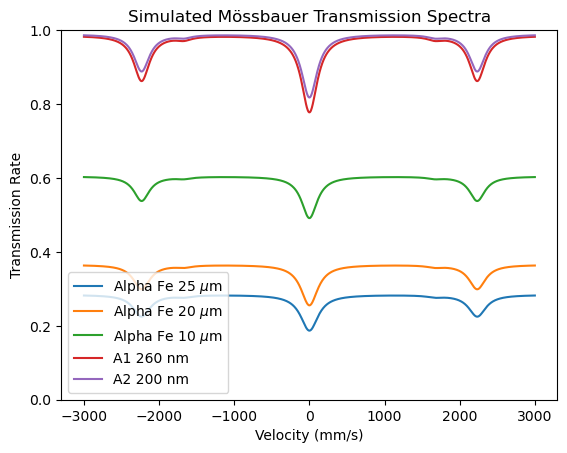

In [144]:

plt.plot(v*1e3, t_Alpha25, label='Alpha Fe 25 $\mu$m')
plt.plot(v*1e3, t_Alpha20, label='Alpha Fe 20 $\mu$m')
plt.plot(v*1e3, t_Alpha10, label='Alpha Fe 10 $\mu$m')
plt.plot(v*1e3, t_A1, label='A1 260 nm')
plt.plot(v*1e3, t_A2, label='A2 200 nm')
plt.xlabel('Velocity (mm/s)')
plt.ylabel('Transmission Rate')
plt.ylim(0,1)
plt.legend()
plt.title('Simulated Mössbauer Transmission Spectra')

moss_Alpha25.non_resonant_attenuation(),25e-6*0.0212





### Detection Model

### SDD detector
 - alphaFe20mum: source-5cm-absorber-0.5cm-detector

Measured visibility: 0.204
Theoretical max visibility: 0.297
Theoretical visibility with SNR=7: 0.275
Actual visibility from reemitted: 0.204
Solid angle ratio: 76.174
Absorber relative solid angle: 0.105
Reemitted detected fraction: 0.032


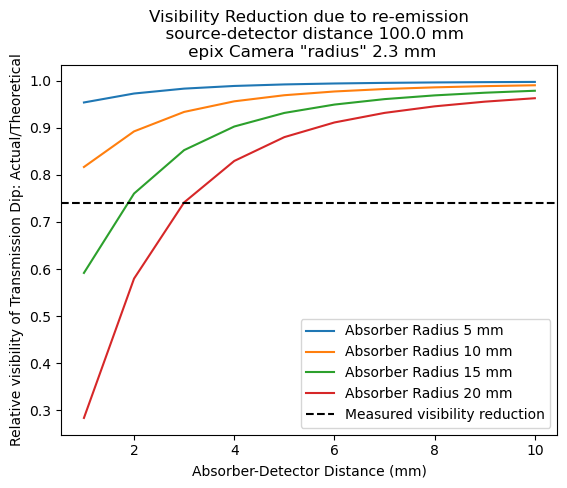

In [149]:
t = t_Alpha20
moss = moss_Alpha20
absorber = absorberAlpha20
source = sourceFe

visibility_meas = (3830-3050)/3830
visibility_theory_max = (t.max()-t.min())/t.max()

SNR = 7
vis_reduction = 1-0.5/(SNR)
visibility_theory = (t.max()-t.min())/t.max()*vis_reduction

d_sd = 100e-3
d_sa = 97e-3
d_ad = d_sd - d_sa
r_a = 20e-3
r_d = np.sqrt(17e-6/np.pi)

def compute_solid_angle(r, d):
    return 2*np.pi*(1-d/np.sqrt(r**2 + d**2))

s_d_solid_angle = compute_solid_angle(r_d, d_sd)
s_a_solid_angle = compute_solid_angle(r_a, d_sa)
a_d_solid_angle = compute_solid_angle(r_d, d_ad)
solid_angle_ratio =  s_a_solid_angle/s_d_solid_angle
reemitted_fraction = visibility_theory_max*1/(absorber.alpha+1)
visibility_actual_from_reemitted = visibility_theory*(1-reemitted_fraction*solid_angle_ratio*a_d_solid_angle/(4*np.pi)
)

print(f"Measured visibility: {visibility_meas:.3f}")
print(f"Theoretical max visibility: {visibility_theory_max:.3f}")
print(f"Theoretical visibility with SNR={SNR}: {visibility_theory:.3f}")
print(f"Actual visibility from reemitted: {visibility_actual_from_reemitted:.3f}")
print(f"Solid angle ratio: {solid_angle_ratio:.3f}")
print(f"Absorber relative solid angle: {a_d_solid_angle/(4*np.pi):.3f}")
print(f"Reemitted detected fraction: {reemitted_fraction:.3f}")


vlist = []
dlist = np.linspace(1e-3,10e-3,10)
ralist = [5e-3,10e-3,15e-3,20e-3]

for r_a in ralist:
    vlist = []

    for d_ad in dlist:
        d_sd = 100e-3
        d_sa = d_sd - d_ad
        #r_a = 20e-3
        r_d = np.sqrt(17e-6/np.pi)


        s_d_solid_angle = compute_solid_angle(r_d, d_sd)
        s_a_solid_angle = compute_solid_angle(r_a, d_sa)
        a_d_solid_angle = compute_solid_angle(r_d, d_ad)
        solid_angle_ratio =  s_a_solid_angle/s_d_solid_angle
        reemitted_fraction = visibility_theory_max*1/(absorber.alpha+1)
        visibility_actual_from_reemitted = visibility_theory*(1-reemitted_fraction*solid_angle_ratio*a_d_solid_angle/(4*np.pi)
        )

        vlist.append(visibility_actual_from_reemitted)
    plt.plot(dlist*1e3, np.array(vlist)/visibility_theory, label=f'Absorber Radius {r_a*1e3:.0f} mm')
    #plt.axvline(3, color='k', linestyle='--')
plt.axhline (visibility_meas/visibility_theory, color='k', linestyle='--', label='Measured visibility reduction')
plt.xlabel('Absorber-Detector Distance (mm)')
plt.ylabel('Relative visibility of Transmission Dip: Actual/Theoretical')
plt.title(f'Visibility Reduction due to re-emission\n  source-detector distance {d_sd*1e3:.1f} mm\n epix Camera "radius" {r_d*1e3:.1f} mm')
plt.legend()    



### Iron analytics detector
 - alphaFe25mum: source-10cm-absorber-10cm-detector
 - A1,A2: source-18cm-absorber-200mumquartz-1cm-detector

### SLAC camera
- A2: source-22mm-quartz200mu-absorber-10mm-camera

Measured visibility: 0.058
Theoretical max visibility: 0.171
Theoretical visibility with SNR=1: 0.085
Actual visibility from reemitted: 0.084
Solid angle ratio: 2.816
Absorber relative solid angle: 0.252
Reemitted detected fraction: 0.019


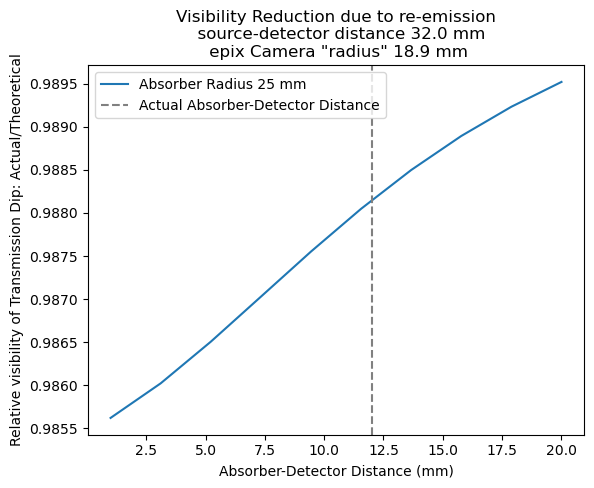

In [132]:
t = t_A2
moss = moss_A2
absorber = absorberA2
source = sourceFe

visibility_meas = 70/1200
visibility_theory_max = (t.max()-t.min())/t.max()

SNR = 1
vis_reduction = 1-0.5/(SNR)
visibility_theory = (t.max()-t.min())/t.max()*vis_reduction

d_sd = 32e-3
d_sa = 22e-3
d_ad = d_sd - d_sa
r_a = 25.4e-3
r_d = 35e-3/2

def compute_solid_angle(r, d):
    return 2*np.pi*(1-d/np.sqrt(r**2 + d**2))

s_d_solid_angle = compute_solid_angle(r_d, d_sd)
s_a_solid_angle = compute_solid_angle(r_a, d_sa)
a_d_solid_angle = compute_solid_angle(r_d, d_ad)
solid_angle_ratio =  s_a_solid_angle/s_d_solid_angle
reemitted_fraction = visibility_theory_max*1/(absorber.alpha+1)
visibility_actual_from_reemitted = visibility_theory*(1-reemitted_fraction*solid_angle_ratio*a_d_solid_angle/(4*np.pi)
)

print(f"Measured visibility: {visibility_meas:.3f}")
print(f"Theoretical max visibility: {visibility_theory_max:.3f}")
print(f"Theoretical visibility with SNR={SNR}: {visibility_theory:.3f}")
print(f"Actual visibility from reemitted: {visibility_actual_from_reemitted:.3f}")
print(f"Solid angle ratio: {solid_angle_ratio:.3f}")
print(f"Absorber relative solid angle: {a_d_solid_angle/(4*np.pi):.3f}")
print(f"Reemitted detected fraction: {reemitted_fraction:.3f}")


vlist = []
dlist = np.linspace(1e-3,20e-3,10)
ralist = [25.4e-3]

for r_a in ralist:
    vlist = []

    for d_ad in dlist:
        #d_sd = 100e-3
        d_sa = d_sd - d_ad
        #r_a = 20e-3
        r_d = np.sqrt((35e-3*32e-3)/np.pi)


        s_d_solid_angle = compute_solid_angle(r_d, d_sd)
        s_a_solid_angle = compute_solid_angle(r_a, d_sa)
        a_d_solid_angle = compute_solid_angle(r_d, d_ad)
        solid_angle_ratio =  s_a_solid_angle/s_d_solid_angle
        reemitted_fraction = visibility_theory_max*1/(absorber.alpha+1)
        visibility_actual_from_reemitted = visibility_theory*(1-reemitted_fraction*solid_angle_ratio*a_d_solid_angle/(4*np.pi)
        )

        vlist.append(visibility_actual_from_reemitted)
    plt.plot(dlist*1e3, np.array(vlist)/visibility_theory, label=f'Absorber Radius {r_a*1e3:.0f} mm')
    plt.axvline(x=d_sa*1e3, color='gray', linestyle='--', label='Actual Absorber-Detector Distance')
    plt.xlabel('Absorber-Detector Distance (mm)')
    plt.ylabel('Relative visibility of Transmission Dip: Actual/Theoretical')
    plt.title(f'Visibility Reduction due to re-emission\n  source-detector distance {d_sd*1e3:.1f} mm\n epix Camera "radius" {r_d*1e3:.1f} mm')

plt.legend()    

